In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [3]:
df.shape

(1000, 9)

In [4]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df = df.drop('Order_ID', axis=1)

In [6]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


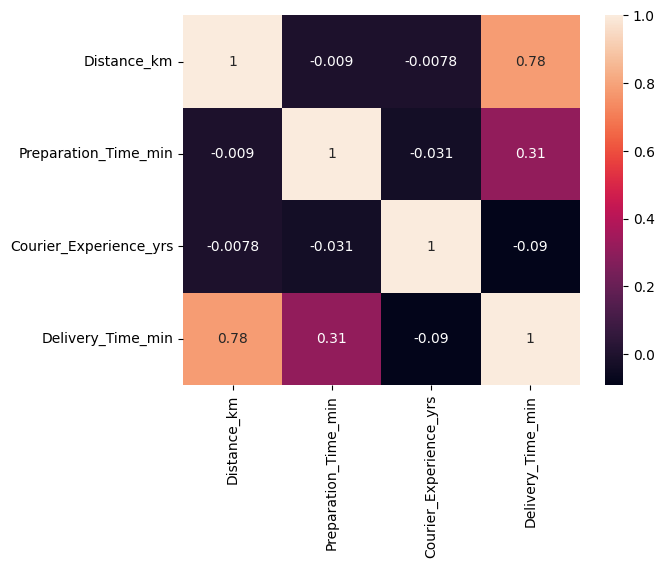

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [8]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [9]:
cat_cols

['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

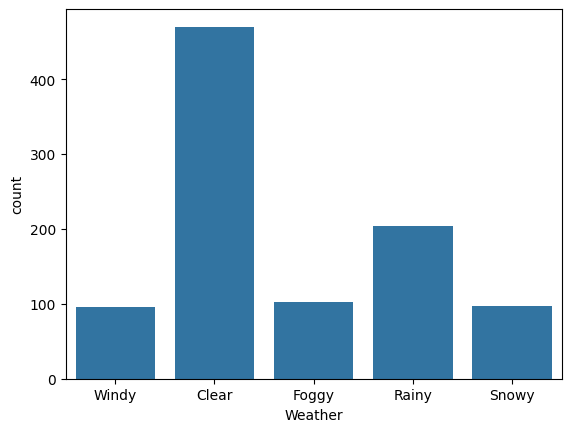

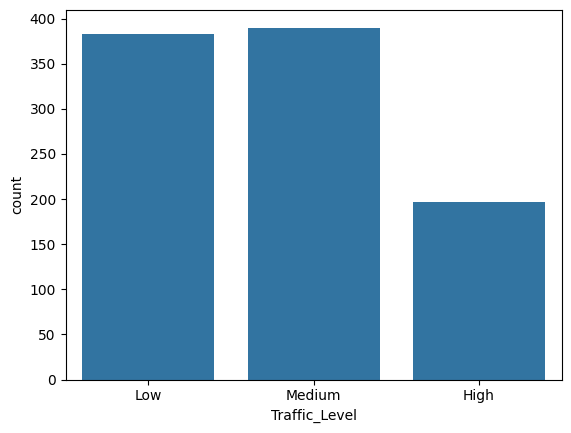

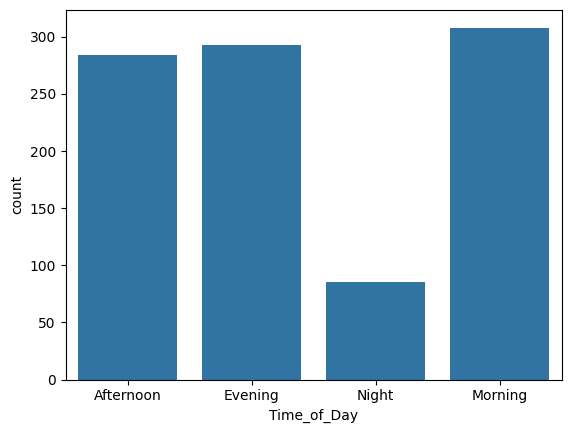

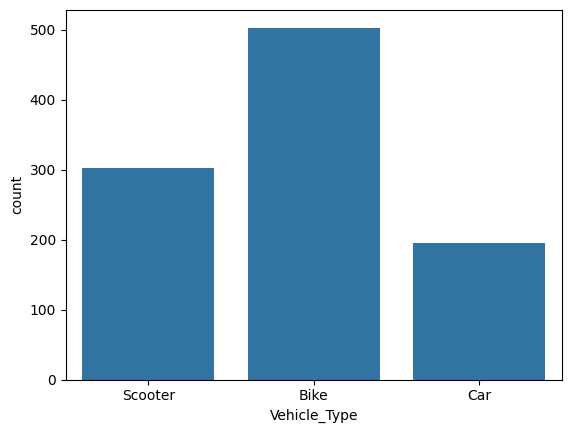

In [10]:
for col in cat_cols:
    sns.countplot(x = df[col])
    plt.show()
    print()

In [11]:
df.isna().sum()

,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [12]:
missing_cols = [col for col in df.columns if df[col].isna().sum() > 0]
missing_cols

['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']

In [13]:
for col in missing_cols:
    if col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [14]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [15]:
df.isna().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
from scipy.stats import f_oneway

for col in cat_cols:
    gp = [df['Delivery_Time_min'][df[col]==category] for category in df[col].unique()]

    f_stats, p_value = f_oneway(*gp)

    print(f"Column: {col}")
    print(f"  F-statistic: {f_stats:.3f}")
    print(f"  P-value: {p_value:.3f}")

    if p_value < 0.05:
        print(f"  (Result: Reject null hypothesis - there is a significant difference in Delivery_Time_min across categories in {col}). \nThus {col} is significant.")
    else:
        print(f"  (Result: Fail to reject null hypothesis - no significant difference in Delivery_Time_min across categories in {col}). \nThus {col} is not significant.")
    print()

Column: Weather
  F-statistic: 10.499
  P-value: 0.000
  (Result: Reject null hypothesis - there is a significant difference in Delivery_Time_min across categories in Weather). 
Thus Weather is significant.

Column: Traffic_Level
  F-statistic: 19.751
  P-value: 0.000
  (Result: Reject null hypothesis - there is a significant difference in Delivery_Time_min across categories in Traffic_Level). 
Thus Traffic_Level is significant.

Column: Time_of_Day
  F-statistic: 0.347
  P-value: 0.792
  (Result: Fail to reject null hypothesis - no significant difference in Delivery_Time_min across categories in Time_of_Day). 
Thus Time_of_Day is not significant.

Column: Vehicle_Type
  F-statistic: 0.589
  P-value: 0.555
  (Result: Fail to reject null hypothesis - no significant difference in Delivery_Time_min across categories in Vehicle_Type). 
Thus Vehicle_Type is not significant.



In [18]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.870301,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,4.579381,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   object 
 2   Traffic_Level           1000 non-null   object 
 3   Time_of_Day             1000 non-null   object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [20]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [22]:
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [23]:
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 7), (200, 7), (800,), (200,))

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
rfr = RandomForestRegressor(n_estimators=400,random_state=42)

In [29]:
rfr.fit(X_train, y_train)

RandomForestRegressor(n_estimators=400, random_state=42)

In [30]:
y_pred = rfr.predict(X_test)

In [31]:
from sklearn.metrics import r2_score

In [32]:
r2_score(y_test, y_pred)

0.7836789177793237

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [35]:
params = {
    'n_estimators': randint(100, 1001), # samples from 100 to 1000
    'max_depth': randint(5, 31), # can be None, or samples from 2 to 51
    'min_samples_split': randint(2, 21), # samples from 2 to 10
    'min_samples_leaf': randint(1, 11), # samples from 1 to 10
    'max_features': ['auto', 'sqrt', 'log2']
}

In [36]:
r_rcv = RandomizedSearchCV(RandomForestRegressor(), params, n_iter=100, cv=5, verbose=3, random_state=42, n_jobs=-1, scoring='r2')

In [37]:
r_rcv.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x796a238a1e80>,
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x796a22d539e0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x796a23a142f0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x796a25b54bf0>},
                   random_state=42, scoring='r2', verbose=3)

In [38]:
print('Best params: ',r_rcv.best_params_)
print('Best score: ', r_rcv.best_score_)

Best params:  {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 819}
Best score:  0.7025028388768243


### Train a new model with the best parameters

In [39]:
# Create a new RandomForestRegressor with the best parameters
best_rfr = RandomForestRegressor(**r_rcv.best_params_, random_state=42)

# Train the model
best_rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=18, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=819, random_state=42)

### Evaluate the new model

In [40]:
# Make predictions on the test set
best_y_pred = best_rfr.predict(X_test)

# Calculate the R2 score
best_r2_score = r2_score(y_test, best_y_pred)

print(f"R2 score of the model with best parameters: {best_r2_score}")
print(f"Original R2 score: {r2_score(y_test, y_pred)}")

R2 score of the model with best parameters: 0.7849343419075716
Original R2 score: 0.7836789177793237


In [43]:
import pickle
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [44]:
df_org = pd.read_csv('Food_Delivery_Times.csv')

In [45]:
df_org['Weather'].fillna(df_org['Weather'].mode()[0], inplace=True)
df_org['Traffic_Level'].fillna(df_org['Traffic_Level'].mode()[0], inplace=True)
df_org['Time_of_Day'].fillna(df_org['Time_of_Day'].mode()[0], inplace=True)
df_org['Courier_Experience_yrs'].fillna(df_org['Courier_Experience_yrs'].median(), inplace=True)

df_org.drop('Order_ID', inplace=True, axis=1)
cat_cols_org = df_org.select_dtypes(include='object').columns

label_encode = {}
for col in cat_cols_org:
    le = LabelEncoder()
    df_org[col] = le.fit_transform(df_org[col])
    label_encode[col] = le

with open('optimized_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rfr, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encode, f)